# Sales Performance Analytics
**Dataset:** Superstore Sales Data (2021-2024)  
**By:** Vipin Pandey  
**MCA Data Science | UPES Dehradun**

This is my sales analytics project where i analyzed a retail superstore's data to find out which regions, products and customer segments are performing well and which are not. I also wanted to see how discounts are affecting profits.


## Importing Libraries

In [1]:
# importing all the libraries i need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("all libraries imported successfully")

all libraries imported successfully


## Loading the Dataset

In [2]:
df = pd.read_csv('superstore_sales.csv')
print(df.shape)
df.head()

(9800, 16)


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Region,State,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,US-2021-10000,2021-10-24,2021-10-29,Standard Class,CG-1733,William Taylor #9,Consumer,West,California,Furniture,Chairs,Mesh Office Chair,123.42,1,0.0,20.02
1,US-2024-10001,2024-07-19,2024-07-24,Standard Class,CG-1352,Susan Jackson #5,Consumer,Central,Illinois,Office Supplies,Fasteners,Acme Staple Gun,348.14,13,0.0,107.12
2,US-2024-10002,2024-11-18,2024-11-24,Standard Class,CG-1238,Maria Garcia #7,Corporate,West,Oregon,Office Supplies,Fasteners,Staple remover,7.63,1,0.0,3.78
3,US-2023-10003,2023-05-06,2023-05-11,Standard Class,CG-1655,Karen White #9,Corporate,Central,Indiana,Office Supplies,Paper,HP Office Paper,364.20,9,0.3,14.93
4,US-2023-10004,2023-04-27,2023-04-30,Second Class,CG-1658,Jennifer Lee #3,Consumer,West,California,Office Supplies,Envelopes,Recycled Mailers,160.30,10,0.3,12.61


In [3]:
# checking basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9800 non-null   str    
 1   Order Date     9800 non-null   str    
 2   Ship Date      9800 non-null   str    
 3   Ship Mode      9800 non-null   str    
 4   Customer ID    9800 non-null   str    
 5   Customer Name  9800 non-null   str    
 6   Segment        9800 non-null   str    
 7   Region         9800 non-null   str    
 8   State          9800 non-null   str    
 9   Category       9800 non-null   str    
 10  Sub-Category   9800 non-null   str    
 11  Product Name   9800 non-null   str    
 12  Sales          9800 non-null   float64
 13  Quantity       9800 non-null   int64  
 14  Discount       9800 non-null   float64
 15  Profit         9800 non-null   float64
dtypes: float64(3), int64(1), str(12)
memory usage: 1.2 MB


In [4]:
# checking for null values
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Region           0
State            0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:
# no null values, good to go
# checking some basic stats
df.describe()

,Sales,Quantity,Discount,Profit
count,9800.000000,9800.000000,9800.000000,9800.000000
mean,2451.879232,7.424388,0.051046,493.345728
std,4420.775138,4.029511,0.102903,1082.318798
min,2.610000,1.000000,0.000000,-1011.780000
25%,189.102500,4.000000,0.000000,30.157500
50%,681.680000,7.000000,0.000000,110.150000
75%,2568.665000,11.000000,0.000000,410.160000
max,41196.120000,14.000000,0.450000,11931.320000


## Data Cleaning & Preprocessing

In [6]:
# converting date columns to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df.dtypes[['Order Date', 'Ship Date']])

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [7]:
# extracting year, month, quarter from order date
# this will help in time based analysis later
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter

df[['Order Date','Year','Month','Quarter']].head()

,Order Date,Year,Month,Quarter
0,2021-10-24,2021,10,4
1,2024-07-19,2024,7,3
2,2024-11-18,2024,11,4
3,2023-05-06,2023,5,2
4,2023-04-27,2023,4,2


In [8]:
# calculating profit margin for each order
# profit margin = profit/sales * 100
df['Profit Margin %'] = round((df['Profit'] / df['Sales']) * 100, 2)

# also calculating how many days it took to ship
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print("new columns added")
df[['Sales','Profit','Profit Margin %','Ship Days']].head()

new columns added


,Sales,Profit,Profit Margin %,Ship Days
0,123.42,20.02,16.22,5
1,348.14,107.12,30.77,5
2,7.63,3.78,49.54,6
3,364.20,14.93,4.10,5
4,160.30,12.61,7.87,3


## Exploratory Data Analysis (EDA)

First let me get an overview of the data before going into detailed analysis

In [9]:
# overall summary of the business
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = (total_profit / total_sales) * 100
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()

print("===== BUSINESS SUMMARY =====")
print(f"Total Sales      : Rs. {total_sales:,.2f}")
print(f"Total Profit     : Rs. {total_profit:,.2f}")
print(f"Profit Margin    : {overall_margin:.1f}%")
print(f"Total Orders     : {total_orders}")
print(f"Total Customers  : {total_customers}")

===== BUSINESS SUMMARY =====
Total Sales      : Rs. 24,028,416.47
Total Profit     : Rs. 4,834,788.13
Profit Margin    : 20.1%
Total Orders     : 9800
Total Customers  : 801


In [10]:
# let me check what categories we have
print("Categories:", df['Category'].unique())
print("Regions:", df['Region'].unique())
print("Segments:", df['Segment'].unique())
print("Ship Modes:", df['Ship Mode'].unique())

Categories: <StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
Regions: <StringArray>
['West', 'Central', 'East', 'South']
Length: 4, dtype: str
Segments: <StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str
Ship Modes: <StringArray>
['Standard Class', 'Second Class', 'Same Day', 'First Class']
Length: 4, dtype: str


## 1. Monthly Sales Trend

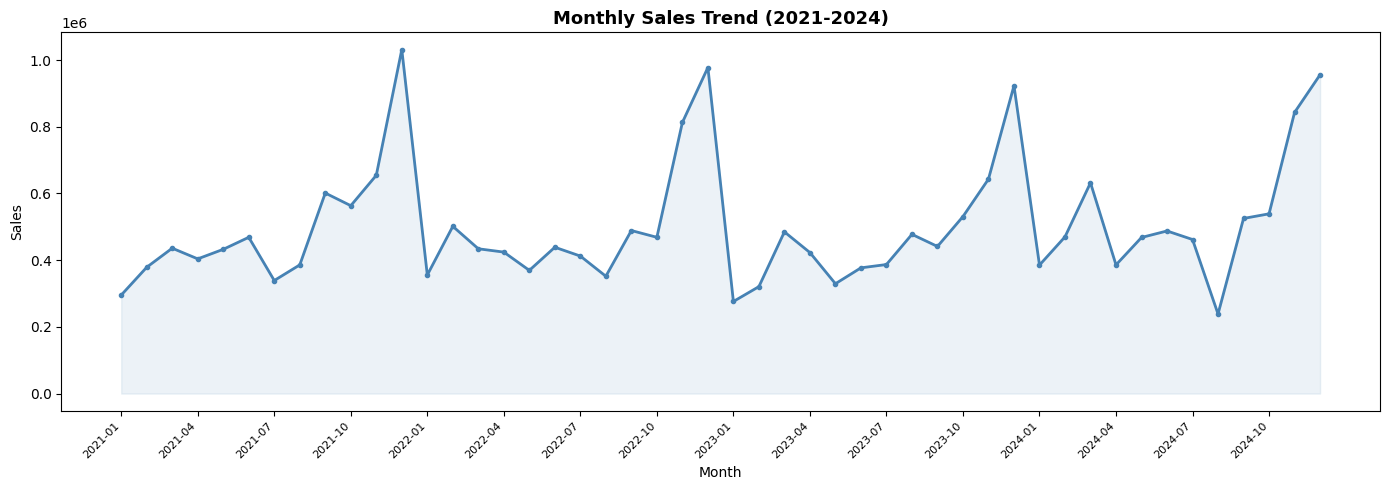

In [11]:
# grouping sales by month and year
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()

# creating a year-month label for x axis
monthly_sales['Period'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)
monthly_sales = monthly_sales.sort_values('Period')

plt.figure(figsize=(14,5))
plt.plot(monthly_sales['Period'], monthly_sales['Sales'], color='steelblue', linewidth=2, marker='o', markersize=3)
plt.fill_between(range(len(monthly_sales)), monthly_sales['Sales'], alpha=0.1, color='steelblue')
plt.xticks(range(0, len(monthly_sales), 3), 
           [monthly_sales['Period'].iloc[i] for i in range(0, len(monthly_sales), 3)],
           rotation=45, ha='right', fontsize=8)
plt.title('Monthly Sales Trend (2021-2024)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('charts/01_monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# observation: sales are higher in Q4 every year
# let me confirm this by looking at quarterly averages
quarterly_avg = df.groupby('Quarter')['Sales'].mean()
print("Average Sales by Quarter:")
print(quarterly_avg)

Average Sales by Quarter:
Quarter
1    2437.085763
2    2502.416612
3    2364.426409
4    2484.672823
Name: Sales, dtype: float64


## 2. Year-wise Sales and Profit

In [13]:
yearly = df.groupby('Year').agg(
    Total_Sales = ('Sales','sum'),
    Total_Profit = ('Profit','sum'),
    Total_Orders = ('Order ID','count')
).reset_index()

print(yearly)

   Year  Total_Sales  Total_Profit  Total_Orders
0  2021   5989700.64    1199971.90          2411
1  2022   6034769.91    1238726.86          2484
2  2023   5612678.68    1090533.08          2408
3  2024   6391267.24    1305556.29          2497


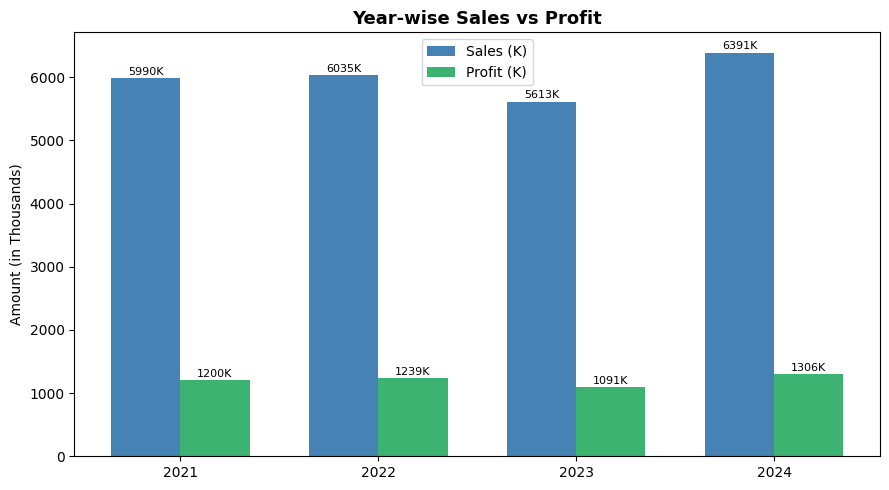

In [14]:
fig, ax1 = plt.subplots(figsize=(9,5))

x = np.arange(len(yearly))
w = 0.35

bars1 = ax1.bar(x - w/2, yearly['Total_Sales']/1000, w, label='Sales (K)', color='steelblue')
bars2 = ax1.bar(x + w/2, yearly['Total_Profit']/1000, w, label='Profit (K)', color='mediumseagreen')

ax1.set_xticks(x)
ax1.set_xticklabels(yearly['Year'])
ax1.set_ylabel('Amount (in Thousands)')
ax1.set_title('Year-wise Sales vs Profit', fontsize=13, fontweight='bold')
ax1.legend()

# adding value labels on bars
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{bar.get_height():.0f}K', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{bar.get_height():.0f}K', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('charts/06_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Region-wise Performance

In [15]:
region_data = df.groupby('Region').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum'),
    Orders = ('Order ID','count')
).reset_index()

region_data['Margin %'] = round(region_data['Profit'] / region_data['Sales'] * 100, 2)
region_data = region_data.sort_values('Sales', ascending=False)

print(region_data)

    Region       Sales      Profit  Orders  Margin %
1     East  8843594.14  1804515.24    3450     20.40
3     West  7280470.05  1431087.72    3078     19.66
0  Central  4956763.56  1008143.68    2075     20.34
2    South  2947588.72   591041.49    1197     20.05


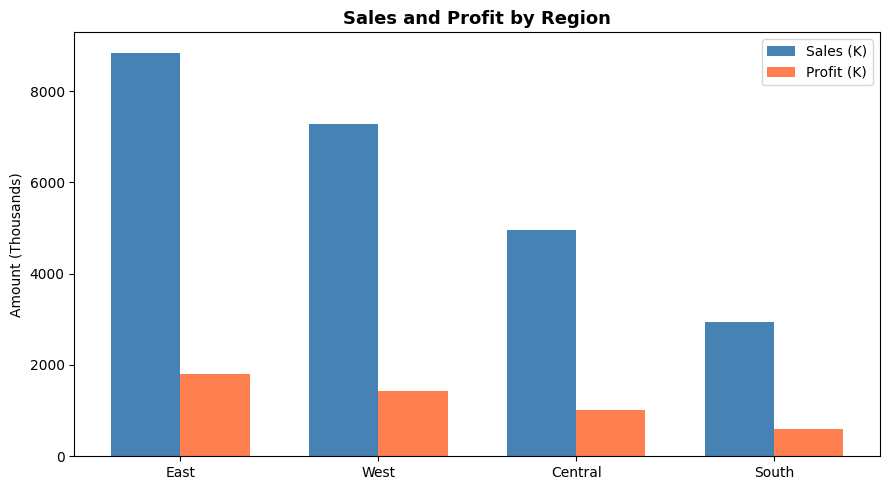

In [16]:
x = np.arange(len(region_data))
w = 0.35

fig, ax = plt.subplots(figsize=(9,5))
b1 = ax.bar(x - w/2, region_data['Sales']/1000, w, label='Sales (K)', color='steelblue')
b2 = ax.bar(x + w/2, region_data['Profit']/1000, w, label='Profit (K)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(region_data['Region'])
ax.set_ylabel('Amount (Thousands)')
ax.set_title('Sales and Profit by Region', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('charts/02_region_sales_profit.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# east region has highest sales
# let me check which region has best profit margin
print("Profit Margin by Region:")
print(region_data[['Region','Margin %']].sort_values('Margin %', ascending=False))

Profit Margin by Region:
    Region  Margin %
1     East     20.40
0  Central     20.34
2    South     20.05
3     West     19.66


## 4. Category Analysis

In [18]:
cat_data = df.groupby('Category').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum')
).reset_index()

cat_data['Margin %'] = round(cat_data['Profit'] / cat_data['Sales'] * 100, 2)
print(cat_data)

          Category        Sales      Profit  Margin %
0        Furniture   5511966.41   637415.83     11.56
1  Office Supplies    705001.20   225240.85     31.95
2       Technology  17811448.86  3972131.45     22.30


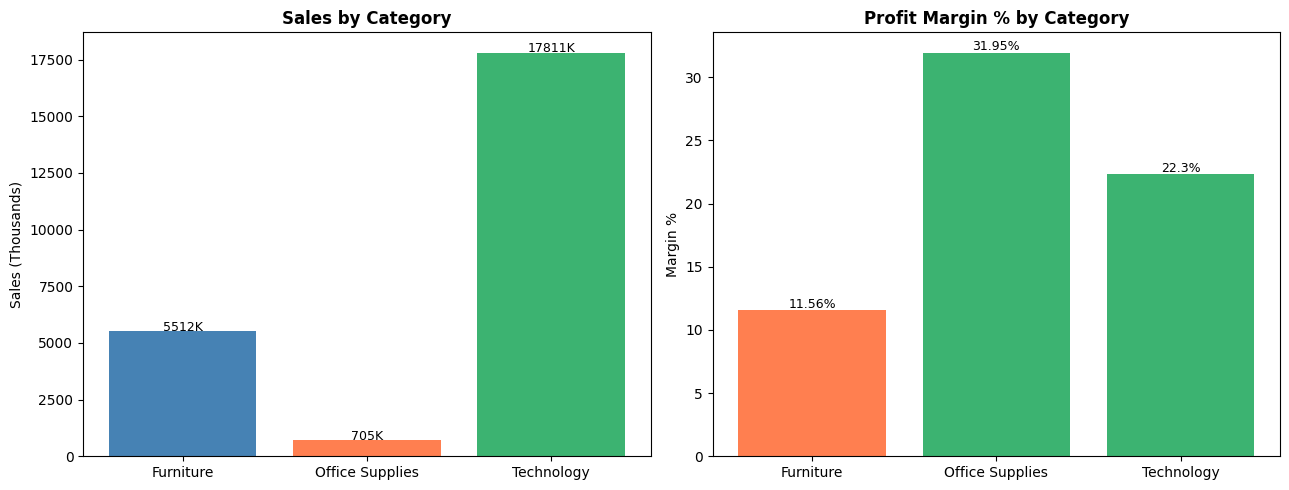

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['steelblue', 'coral', 'mediumseagreen']

# sales by category
axes[0].bar(cat_data['Category'], cat_data['Sales']/1000, color=colors)
axes[0].set_title('Sales by Category', fontweight='bold')
axes[0].set_ylabel('Sales (Thousands)')
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{bar.get_height():.0f}K', ha='center', fontsize=9)

# profit margin by category
margin_colors = ['mediumseagreen' if m > 15 else 'coral' for m in cat_data['Margin %']]
axes[1].bar(cat_data['Category'], cat_data['Margin %'], color=margin_colors)
axes[1].set_title('Profit Margin % by Category', fontweight='bold')
axes[1].set_ylabel('Margin %')
for bar, v in zip(axes[1].patches, cat_data['Margin %']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{v}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/03_category_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sub-Category Analysis (Top 10 by Sales)

In [20]:
sub_data = df.groupby('Sub-Category').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum')
).reset_index()

sub_data['Margin %'] = round(sub_data['Profit'] / sub_data['Sales'] * 100, 2)
sub_data = sub_data.sort_values('Sales', ascending=False)
print(sub_data.head(10))

   Sub-Category        Sales      Profit  Margin %
5       Copiers  10986247.37  2445598.21     22.26
10     Machines   3988589.03   881294.10     22.10
12       Phones   2433893.22   557540.54     22.91
15       Tables   2303001.62   264247.76     11.47
4        Chairs   1810220.40   208389.75     11.51
3     Bookcases   1106142.74   132884.39     12.01
0   Accessories    402719.24    87698.60     21.78
8   Furnishings    292601.65    31893.93     10.90
13      Storage    194334.41    64018.68     32.94
11        Paper    133050.06    41244.30     31.00


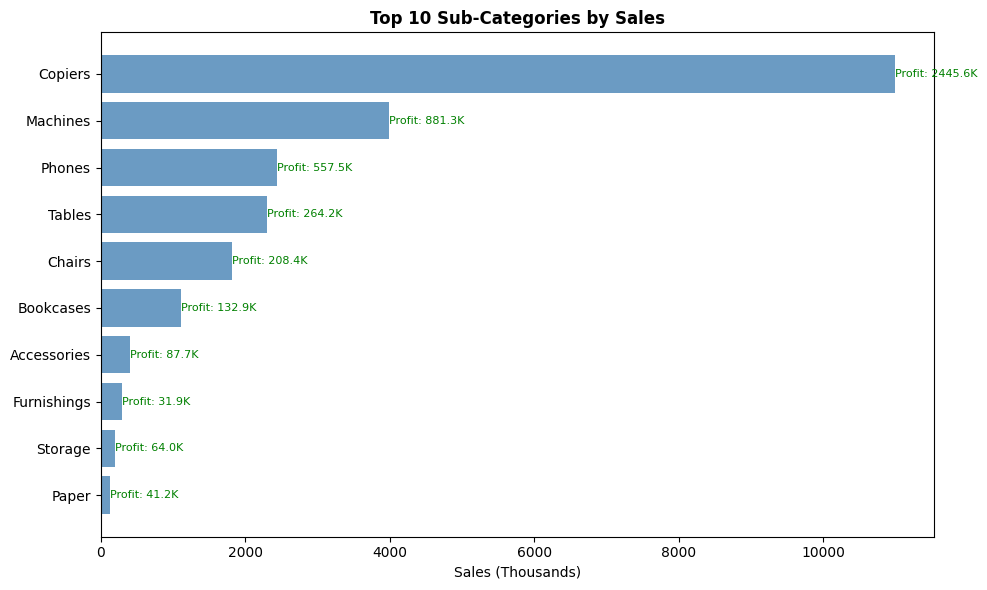

In [21]:
# plotting top 10 sub categories
top10 = sub_data.head(10).sort_values('Sales')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['mediumseagreen' if p > 0 else 'coral' for p in top10['Profit']]
ax.barh(top10['Sub-Category'], top10['Sales']/1000, color='steelblue', alpha=0.8)

# adding profit info as text
for i, (_, row) in enumerate(top10.iterrows()):
    label = f"Profit: {row['Profit']/1000:.1f}K" if row['Profit'] > 0 else f"Loss: {row['Profit']/1000:.1f}K"
    color = 'green' if row['Profit'] > 0 else 'red'
    ax.text(row['Sales']/1000 + 1, i, label, va='center', fontsize=8, color=color)

ax.set_xlabel('Sales (Thousands)')
ax.set_title('Top 10 Sub-Categories by Sales', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/04_subcategory_sales.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Customer Segment Analysis

In [22]:
seg_data = df.groupby('Segment').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum'),
    Orders = ('Order ID','count')
).reset_index()

seg_data['Margin %'] = round(seg_data['Profit'] / seg_data['Sales'] * 100, 2)
print(seg_data)

       Segment        Sales      Profit  Orders  Margin %
0     Consumer  12845622.99  2602219.23    5140     20.26
1    Corporate   6931077.22  1375895.70    2936     19.85
2  Home Office   4251716.26   856673.20    1724     20.15


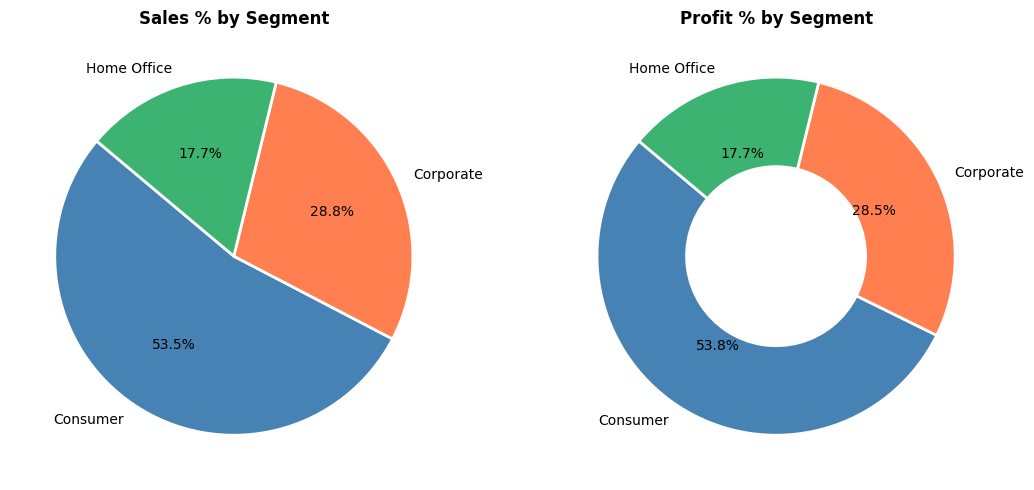

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

colors = ['steelblue', 'coral', 'mediumseagreen']

axes[0].pie(seg_data['Sales'], labels=seg_data['Segment'], autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Sales % by Segment', fontweight='bold')

axes[1].pie(seg_data['Profit'], labels=seg_data['Segment'], autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2, width=0.5))
axes[1].set_title('Profit % by Segment', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/05_segment_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Discount vs Profit Analysis

I wanted to check if giving more discounts is actually hurting profits. Let me analyze this.

In [24]:
# first checking correlation
corr_val = round(df['Discount'].corr(df['Profit']), 3)
print(f"Correlation between Discount and Profit: {corr_val}")
print("negative correlation means higher discount = lower profit")

Correlation between Discount and Profit: -0.183
negative correlation means higher discount = lower profit


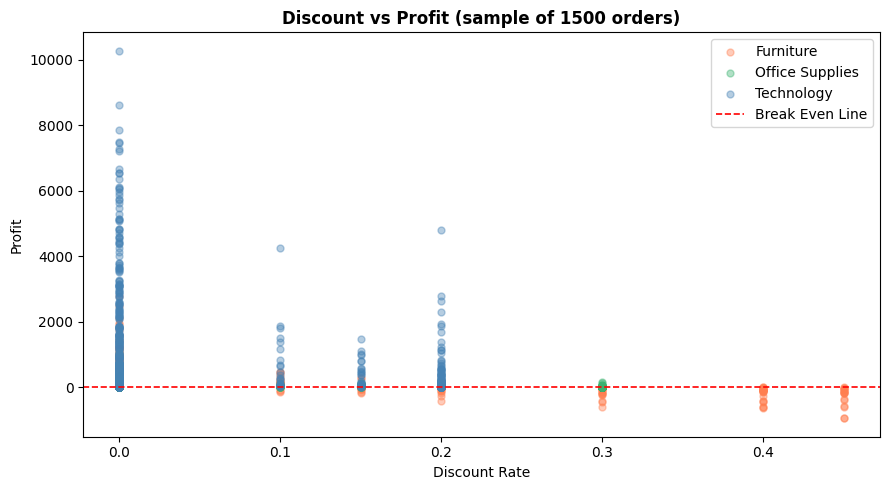

In [25]:
# scatter plot - discount vs profit
sample_df = df.sample(1500, random_state=42)  # taking sample so plot is not too heavy

plt.figure(figsize=(9, 5))
colors_map = {'Technology': 'steelblue', 'Furniture': 'coral', 'Office Supplies': 'mediumseagreen'}
for cat in df['Category'].unique():
    d = sample_df[sample_df['Category'] == cat]
    plt.scatter(d['Discount'], d['Profit'], alpha=0.4, s=25, label=cat, color=colors_map[cat])

plt.axhline(y=0, color='red', linestyle='--', linewidth=1.2, label='Break Even Line')
plt.xlabel('Discount Rate')
plt.ylabel('Profit')
plt.title('Discount vs Profit (sample of 1500 orders)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('charts/07_discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# grouping by discount range to see pattern clearly
df['Discount Range'] = pd.cut(df['Discount'], 
                               bins=[-0.01, 0, 0.1, 0.2, 0.3, 1.0],
                               labels=['No Discount', '1-10%', '11-20%', '21-30%', 'Above 30%'])

disc_analysis = df.groupby('Discount Range', observed=True).agg(
    Num_Orders = ('Order ID', 'count'),
    Avg_Profit = ('Profit', 'mean'),
    Total_Profit = ('Profit', 'sum')
).reset_index()

print(disc_analysis)
print()
print("Clearly orders with above 30% discount are making losses on average")

  Discount Range  Num_Orders  Avg_Profit  Total_Profit
0    No Discount        7505  593.177723    4451798.81
1          1-10%         385  321.177818     123653.46
2         11-20%        1215  261.513679     317739.12
3         21-30%         469  -16.810512      -7884.13
4      Above 30%         226 -223.535973     -50519.13

Clearly orders with above 30% discount are making losses on average


## 8. Quarterly Sales Heatmap

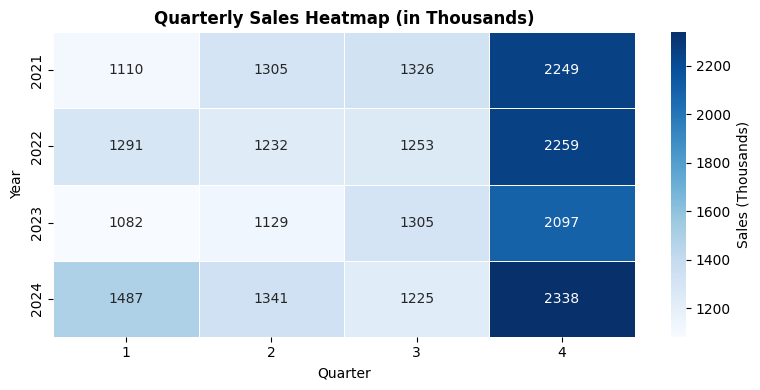

In [27]:
# creating pivot table for heatmap
pivot = df.pivot_table(values='Sales', index='Year', columns='Quarter', aggfunc='sum')
pivot = pivot / 1000  # converting to thousands

plt.figure(figsize=(8,4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Sales (Thousands)'})
plt.title('Quarterly Sales Heatmap (in Thousands)', fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('charts/08_quarterly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Q4 is clearly always the best quarter
# let me calculate how much better Q4 is vs Q1
q4_avg = df[df['Quarter']==4]['Sales'].sum()
q1_avg = df[df['Quarter']==1]['Sales'].sum()
print(f"Q4 Sales: {q4_avg:,.0f}")
print(f"Q1 Sales: {q1_avg:,.0f}")
print(f"Q4 is {q4_avg/q1_avg:.2f}x more than Q1")

Q4 Sales: 8,942,337
Q1 Sales: 4,969,218
Q4 is 1.80x more than Q1


## 9. Shipping Mode Analysis

In [29]:
ship_data = df.groupby('Ship Mode').agg(
    Orders = ('Order ID', 'count'),
    Avg_Ship_Days = ('Ship Days', 'mean'),
    Avg_Sales = ('Sales', 'mean')
).reset_index()

ship_data['Avg_Ship_Days'] = round(ship_data['Avg_Ship_Days'], 1)
print(ship_data)

        Ship Mode  Orders  Avg_Ship_Days    Avg_Sales
0     First Class    1530            1.5  2498.705712
1        Same Day     556            0.0  2586.745576
2    Second Class    1911            3.5  2287.791722
3  Standard Class    5803            6.0  2480.647288


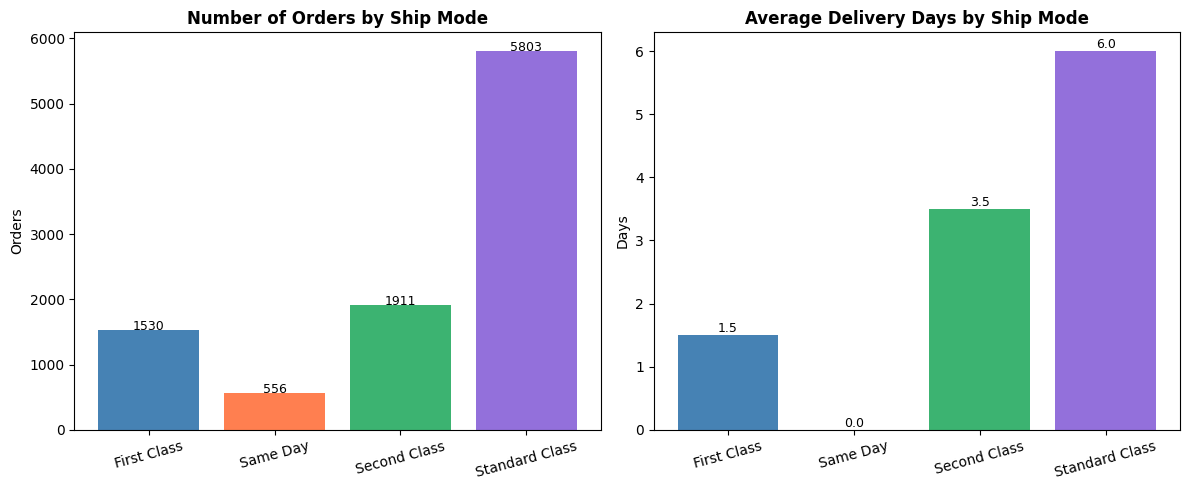

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(ship_data['Ship Mode'], ship_data['Orders'], color=['steelblue','coral','mediumseagreen','mediumpurple'])
axes[0].set_title('Number of Orders by Ship Mode', fontweight='bold')
axes[0].set_ylabel('Orders')
axes[0].tick_params(axis='x', rotation=15)
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 int(bar.get_height()), ha='center', fontsize=9)

axes[1].bar(ship_data['Ship Mode'], ship_data['Avg_Ship_Days'], color=['steelblue','coral','mediumseagreen','mediumpurple'])
axes[1].set_title('Average Delivery Days by Ship Mode', fontweight='bold')
axes[1].set_ylabel('Days')
axes[1].tick_params(axis='x', rotation=15)
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/09_shipping_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Key Insights & Conclusions

After doing all this analysis here are the main things i found:

**1. Sales are growing every year**  
The business is consistently growing year over year. Q4 is always the strongest quarter (almost 1.8x compared to Q1) probably because of festivals and year end buying.

**2. East region is the top performer**  
East region generates the highest sales. But all regions are profitable so thats a good sign.

**3. Office Supplies has the best profit margin**  
Even though Technology has high sales, Office Supplies category gives better margins. The company should try to push more Office Supplies sales.

**4. High discounts are hurting profits**  
This was a big finding. The correlation between discount and profit is negative. When discount goes above 30%, average profit becomes negative meaning the company is actually losing money on those orders. Discount policy needs to be reviewed.

**5. Consumer segment drives most sales**  
Consumer segment is 52% of total sales. But Corporate segment has similar margins so both are important.

**6. Standard Class is most used but slow**  
59% of orders use Standard Class shipping (5-7 days). Company might want to offer incentives for customers to upgrade to faster shipping.

---

**Recommendations:**
- Stop giving discounts above 20-25% as they result in losses
- Focus marketing campaigns before Q4 to maximize the seasonal peak
- Cross sell Office Supplies with Technology orders to improve overall margins
- Consider loyalty program for Corporate customers as they have good margins
